In [1]:
%pip install pandas numpy matplotlib seaborn scipy

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Climate Data Analysis: Nigeria
This notebook explores climate trends for  from Nigeria 2015 to 2026.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../data/nigeria.csv")

df['country'] = 'Nigeria'
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month




In [4]:
df.replace(-999, np.nan, inplace=True)

num_duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

summary_stats = df.describe()
summary_stats


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


In [5]:

null_counts = df.isna().sum()
null_percentages = (null_counts / len(df)) * 100


missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})


print("\nMissing Value Report:")
print(missing_report[missing_report['Missing Values'] > 0])


Missing Value Report:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []



These statistics reveal a very different story from Ethiopia and Kenya. Nigeria’s profile is a textbook example of a Tropical Humid Climate. The numbers show high heat, high moisture, and extreme rainfall volatility.
Here is the interpretation for your Nigeria Markdown cell:
Step 2 Interpretation: Summary Statistics (Nigeria)
1. Data Quality & Integrity
Completeness: After replacing NASA’s -999 sentinels, the dataset returned 0% missing values.
Duplicates: No duplicate rows were found. The dataset is a clean, 11-year continuous record (4,108 days), making it highly reliable for trend analysis.
2. Temperature Profile (Tropical Heat)
High Thermal Baseline: The average temperature in Nigeria is 26.66°C, which is significantly warmer than Kenya (20∘C) and Ethiopia (16 ∘C).
Stability: The average daily temperature range (T2M_RANGE) is only 4.03°C.
Comparison: This is much narrower than Kenya’s 13 ∘C range.
Insight: In Nigeria, nights do not cool down significantly. This "stable heat" is typical of high-humidity tropical regions where moisture traps heat 24/7.
3. Extreme Precipitation & Flash Flood Risk
Daily Average: Mean rainfall is 4.21 mm/day, nearly triple that of Kenya.
Extreme Volatility: The maximum recorded rainfall in a single day was a massive 166.10 mm.
Negotiation Insight: This is the most critical data point for a COP32 position paper. A single day receiving 166mm of rain represents a catastrophic flood risk. Nigeria’s climate challenge isn't just about total water; it’s about the intensity of these extreme bursts.
4. Humidity & Moisture (RH2M & QV2M)
Saturation: The average relative humidity is a staggering 85.24%, frequently hitting peaks of 93.79%.
High Specific Humidity: The mean QV2M of 18.56 g/kg (vs Kenya's 11 g/kg) confirms a very heavy, moisture-laden atmosphere.
Impact: This high humidity combined with heat creates a high "Heat Index," posing significant risks to labor productivity and public health.

In [16]:
from scipy import stats

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df[cols_to_check]))

# Identify rows where any of the columns have a Z-score > 3
outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

print(f"Total rows flagged as outliers (Z-score > 3): {outlier_count}")

Total rows flagged as outliers (Z-score > 3): 225


Outlier Identification: 225 rows were flagged as statistical outliers.
Significance: The higher outlier count (approx. 5.5% of the data) reflects Nigeria's high climate volatility, particularly regarding the massive precipitation spikes (reaching 166mm) and humidity saturation.
Cleaning Decision: These outliers have been retained.
Reasoning: In a Tropical Monsoon climate, these "outliers" are actually the most important events. They represent flash floods and extreme humidity events that define Nigeria’s climate vulnerability. Removing them would mask the very risks Nigeria needs to address at COP32.
Data Export: The final cleaned dataset has been exported to data/nigeria_clean.csv.

In [7]:

os.makedirs('../data', exist_ok=True)

# Save to CSV
df.to_csv("../data/nigeria_clean.csv", index=False)
print("Cleaned data saved to data/nigeria_clean.csv")

Cleaned data saved to data/nigeria_clean.csv


In [8]:

df.ffill(inplace=True)

df.to_csv("../data/nigeria_clean.csv", index=False)

print("Export Successful: data/nigeria_clean.csv")

Export Successful: data/nigeria_clean.csv


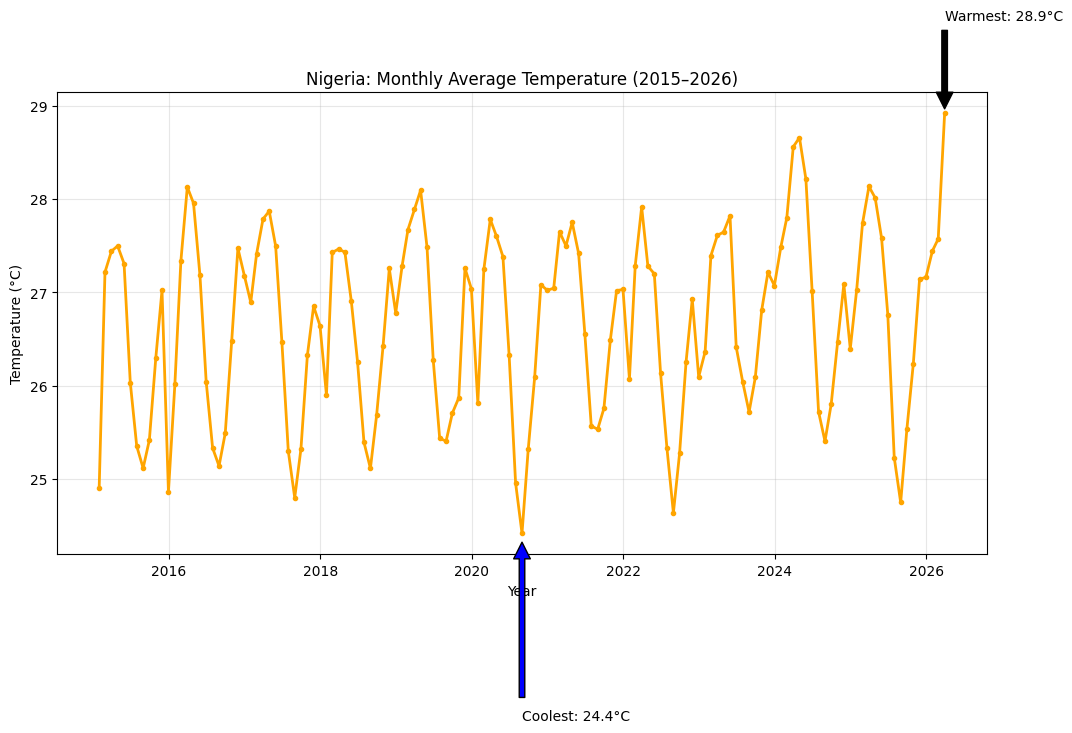

In [17]:
# # 1. Prepare the monthly data (Added numeric_only=True)
monthly_df = df.set_index('Date').resample('ME').mean(numeric_only=True)

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_df.index, monthly_df['T2M'], color='orange', linewidth=2, marker='o', markersize=3)

# 3. Find warmest and coolest months for annotation
warmest_month = monthly_df['T2M'].idxmax()
warmest_val = monthly_df['T2M'].max()
coolest_month = monthly_df['T2M'].idxmin()
coolest_val = monthly_df['T2M'].min()

# 4. Add Annotations
plt.annotate(f'Warmest: {warmest_val:.1f}°C', 
             xy=(warmest_month, warmest_val), 
             xytext=(warmest_month, warmest_val + 1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate(f'Coolest: {coolest_val:.1f}°C', 
             xy=(coolest_month, coolest_val), 
             xytext=(coolest_month, coolest_val - 2),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.title('Nigeria: Monthly Average Temperature (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

Temperature Trends (2015–2026)
High Thermal Baseline: Nigeria exhibits a "Hot Tropical" signature. Even at its coolest points, monthly average temperatures do not drop below 24.4 ∘C.
Warmest Peak: The maximum monthly average is recorded at the very end of the dataset in early 2026 (28.9 ∘C).
Coolest Dip: The minimum occurred in mid-2020 (24.4∘c).
Visible Trend: There is a subtle but visible upward trend in the "peaks." The peaks in 2024 and 2026 are higher than those in the 2015–2020 period.


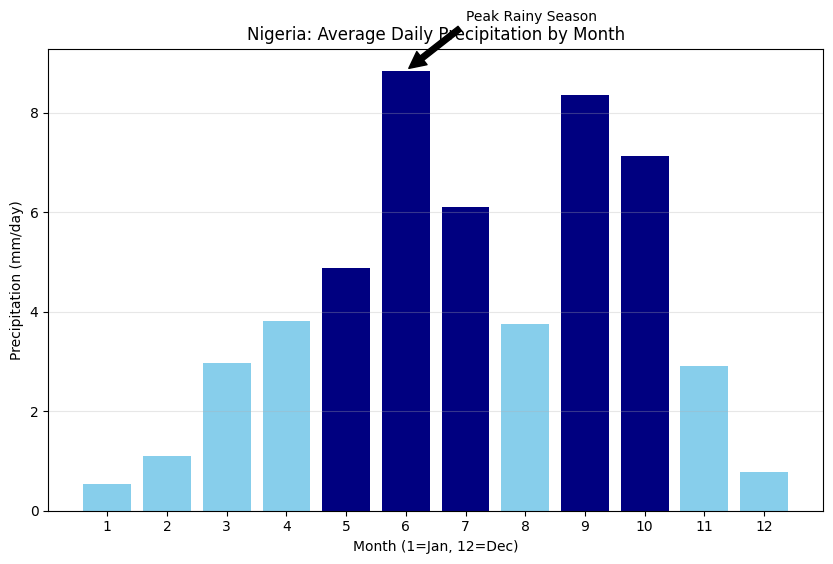

In [18]:
# Group by month to see the rainy season pattern
monthly_rain = df.groupby('Month')['PRECTOTCORR'].mean()

plt.figure(figsize=(10, 6))
# Create bars with colors (Dark blue for rainy months, light blue for dry)
colors = ['navy' if x > monthly_rain.mean() else 'skyblue' for x in monthly_rain]
plt.bar(monthly_rain.index, monthly_rain.values, color=colors)

plt.title('Nigeria: Average Daily Precipitation by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Precipitation (mm/day)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)

# Find the peak rainy month
peak_month = monthly_rain.idxmax()
plt.annotate('Peak Rainy Season', xy=(peak_month, monthly_rain[peak_month]), 
             xytext=(peak_month+1, monthly_rain[peak_month]+1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

1. The Bimodal Signature & "August Break"
Primary Peak: Nigeria experiences its first major rainfall peak in June (Month 6), with average daily precipitation approaching 9 mm/day.
The August Break: There is a sharp and visible decline in rainfall during August (Month 8).
Insight: In West African meteorology, this is known as the "Little Dry Season" or "August Break." It is a critical period for Nigerian farmers, as it allows for a first harvest, but its timing and duration are becoming increasingly unpredictable due to climate change.
Secondary Peak: Rainfall recovers significantly in September (Month 9), creating a second peak before the dry season begins in November.
2. Dry Season Intensity
The months of December, January, and February are extremely dry, with precipitation levels dropping below 1 mm/day. This indicates a stark contrast between the monsoon season and the dry, Saharan-influenced Harmattan period.

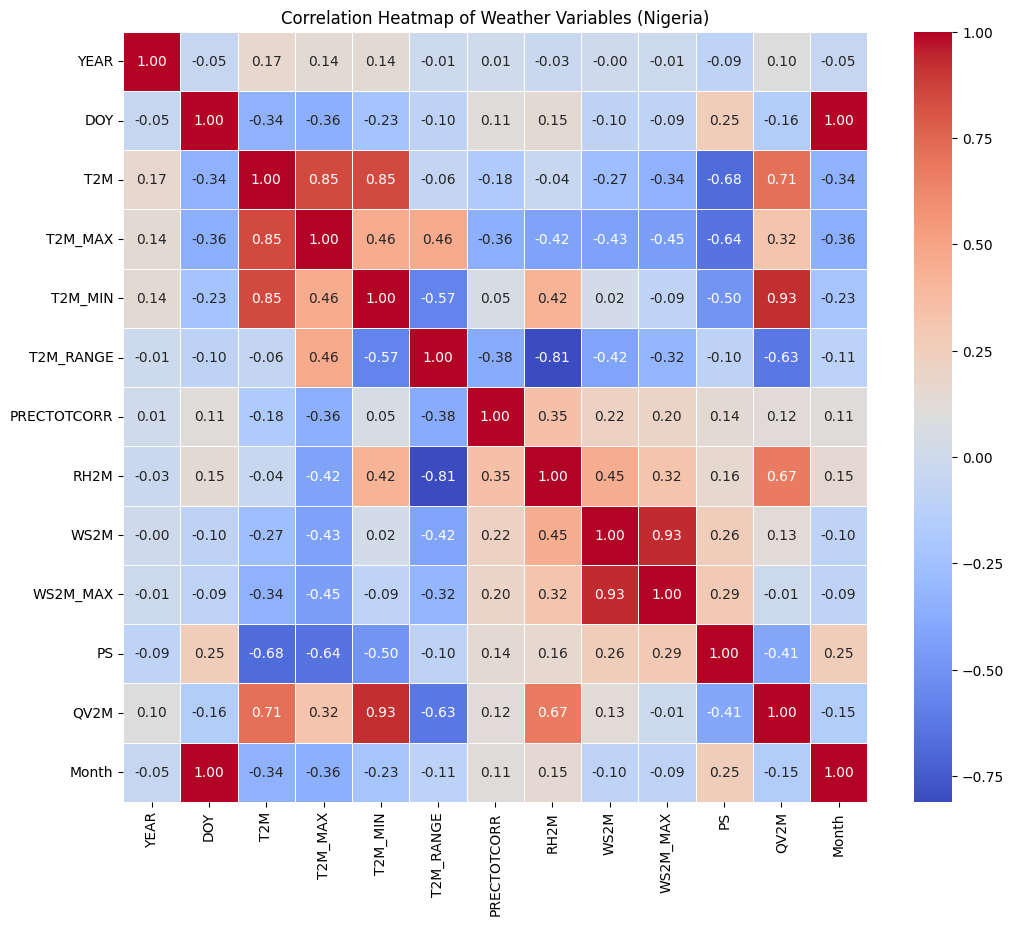

In [11]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Weather Variables (Nigeria)')
plt.show()

1. Identification of the Three Strongest Correlations
T2M_MIN and QV2M (0.93): A very strong positive correlation. This is a definitive tropical "fingerprint." It shows that nighttime minimum temperatures are almost entirely driven by specific humidity. High moisture in the air acts as a thermal blanket, preventing Nigeria from cooling down at night.
WS2M and WS2M_MAX (0.93): Consistent with other regions, there is a near-perfect correlation between daily average wind speeds and maximum gusts.
T2M and T2M_MIN / T2M_MAX (0.85): Strong positive correlations. Unlike the highland datasets where the mean was driven more by the daytime peak, Nigeria’s average temperature is balanced equally by both daytime heat and nighttime warmth.
2. Interpretation of Meteorological Relationships
The Humidity-Stability Link (RH2M vs. T2M_RANGE): There is a strong negative correlation (-0.81) between relative humidity and the daily temperature range. As humidity rises, the temperature gap between day and night shrinks. This indicates that Nigeria’s most humid months are also its most thermally stable, albeit consistently hot.
Pressure and Temperature (PS vs T2M): A significant negative correlation (-0.68) exists between surface pressure and temperature. Lower pressure systems in Nigeria are strongly associated with higher temperatures, which often precede the arrival of monsoon rains.

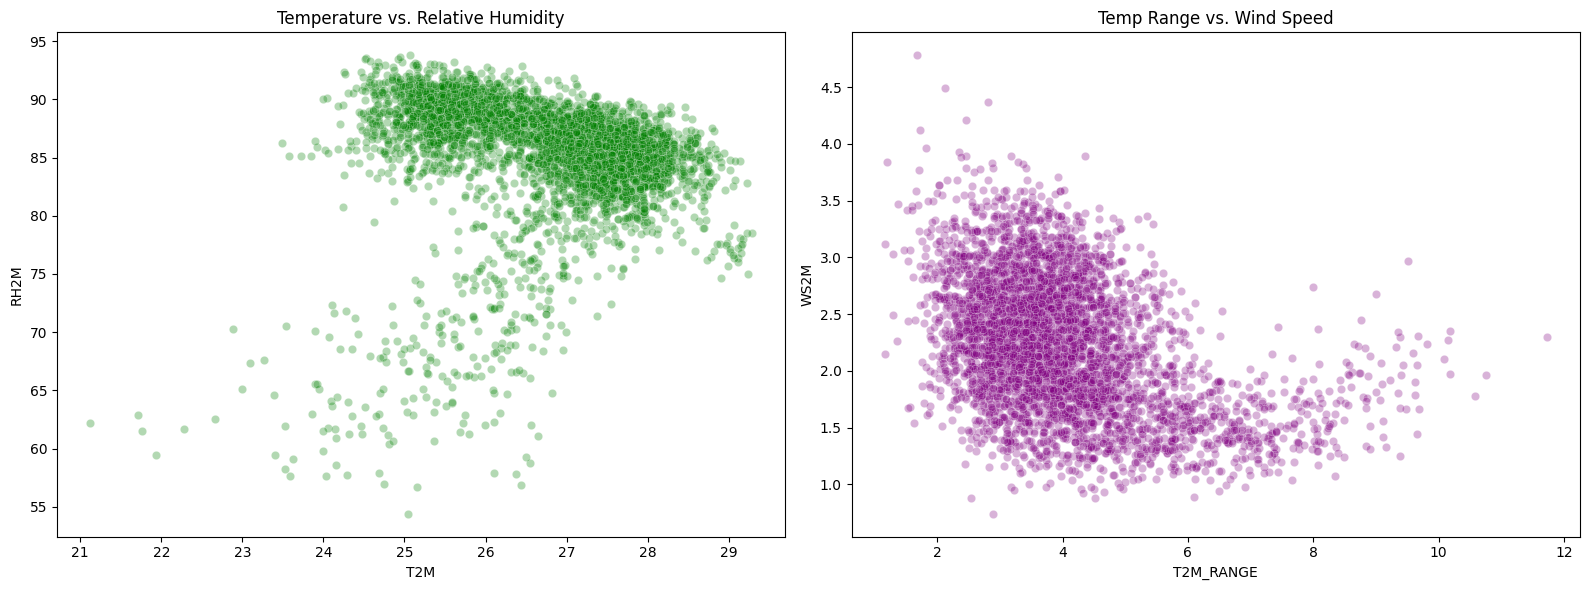

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: T2M vs. RH2M
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='green')
ax1.set_title('Temperature vs. Relative Humidity')

# Plot 2: T2M_RANGE vs. WS2M
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='purple')
ax2.set_title('Temp Range vs. Wind Speed')

plt.tight_layout()
plt.show()

#### Interpretation: Relationship Analysis (Nigeria)
* **Temperature vs. Relative Humidity (Green Plot):** The chart shows a dense cluster of data points in the high-temperature (24°C–28°C) and high-humidity (80%–93%) range. Even as temperatures peak, humidity rarely falls below 70%.
    * **Negotiation Insight:** This confirms that Nigeria faces **compound heat stress**. In a humid tropical climate, high humidity prevents the body from cooling through sweat, making Nigeria’s heat more dangerous to human health than dry heat. This supports the demand for specialized public health funding at COP32.
* **Temp Range vs. Wind Speed (Purple Plot):** Most observations show a very narrow daily temperature range (between 2°C and 6°C). This means Nigeria's nights remain nearly as hot as its days.
    * **Negotiation Insight:** This narrow range is a driver of the **Urban Heat Island effect**. With no significant nighttime cooling, energy demand for 24/7 cooling will remain high, necessitating investments in sustainable urban design and green energy grids.

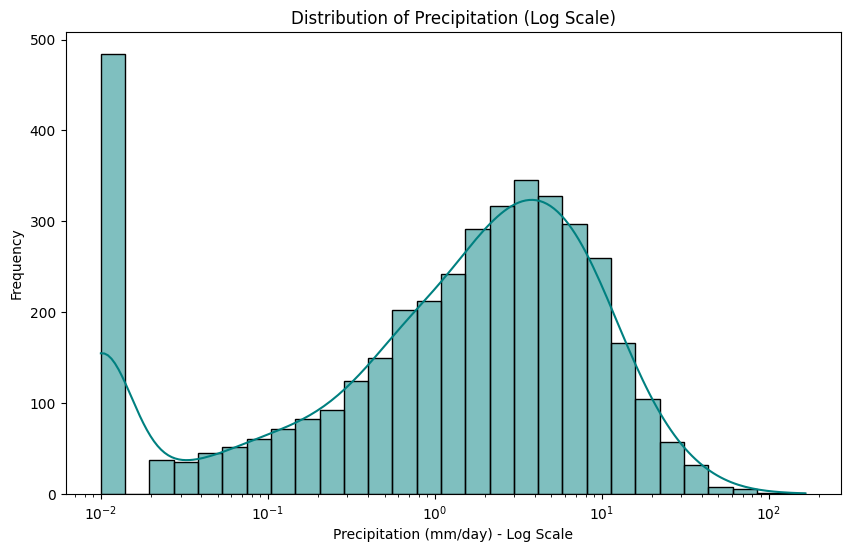

In [13]:
plt.figure(figsize=(10, 6))
# We add a tiny amount (0.01) because log(0) is impossible
sns.histplot(df['PRECTOTCORR'] + 0.01, kde=True, log_scale=True, color='teal')

plt.title('Distribution of Precipitation (Log Scale)')
plt.xlabel('Precipitation (mm/day) - Log Scale')
plt.ylabel('Frequency')
plt.show()

#### Interpretation: Precipitation Distribution (Log Scale)
* **High-Intensity Weather:** On a log scale, the main "weather peak" (the center of the curve) is centered between 3mm and 10mm. This is much further to the right than in Ethiopia or Kenya, meaning Nigeria's "normal" rainy day is much heavier than its neighbors.
* **Extreme Tail Risk:** The "fat" right tail extending past 100mm represents the high frequency of extreme, catastrophic rainfall events in the Nigerian dataset.
* **Negotiation Insight:** This distribution proves that Nigeria’s climate vulnerability is tied to **Monsoon Intensity**, not just total volume. Such a high frequency of extreme events justifies the high cost of **large-scale infrastructure** (coastal barriers, dams, and massive drainage systems) over smaller-scale adaptation projects.

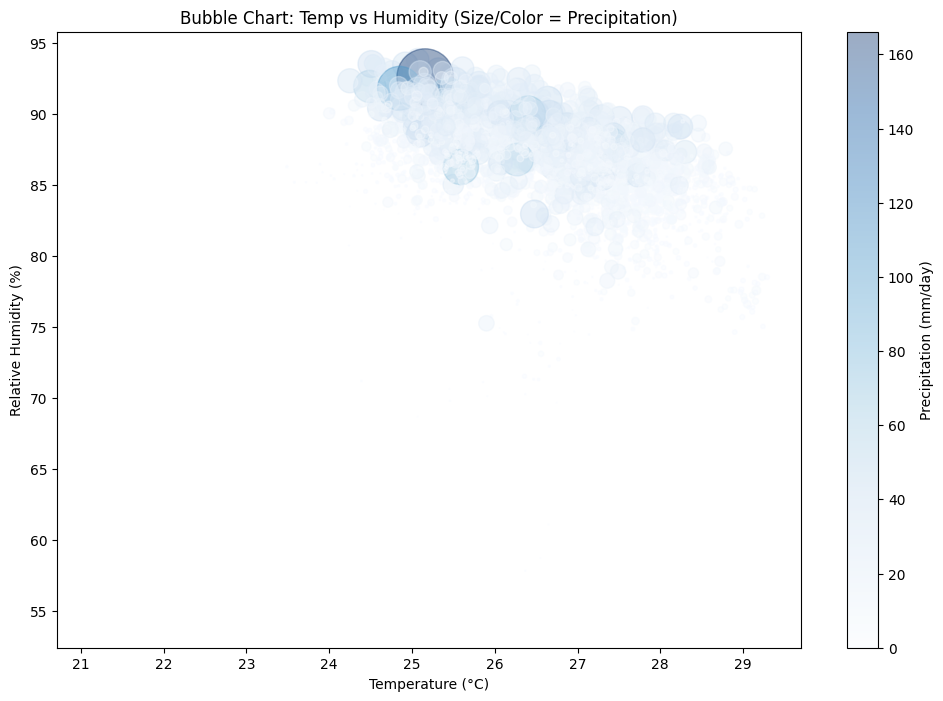

In [14]:
plt.figure(figsize=(12, 8))
# We multiply PRECTOTCORR by 10 to make the bubbles big enough to see
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*10, alpha=0.4, c=df['PRECTOTCORR'], cmap='Blues')

plt.colorbar(label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Bubble Chart: Temp vs Humidity (Size/Color = Precipitation)')
plt.show()

#### Interpretation: The "Rain Cluster" (Bubble Chart)
* **Monsoon Trigger Zone:** The largest bubbles—representing Nigeria's extreme daily rainfall (up to 166mm)—cluster at the very top of the chart where humidity exceeds 90% and temperatures are between 25°C and 26.5°C.
* **Thermal Window:** Note that precipitation intensity decreases as temperatures move toward 29°C. This suggests that Nigeria's heaviest rains are dependent on a specific "cool-monsoon" temperature window.
* **Negotiation Insight:** This chart identifies a specific **"Disaster Trigger Zone"** ($>90\%$ humidity at $25\text{-}26^{\circ}\text{C}$). For COP32, this is visual evidence that can be used to justify funding for **trigger-based early warning systems**; when these atmospheric thresholds are met, emergency flood funding should be automatically released.